<a href="https://colab.research.google.com/github/MavelSterling/Lab-curso-NLP/blob/main/Sesion5/1-text-generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de texto con GPT-2 en español

En este notebook se construye una versión propia del ejercicio de generación de texto con modelos tipo GPT.  
Se mantiene la idea base del notebook guía: usar un modelo GPT-2 en español preentrenado, explorar su generación de texto y luego realizar fine-tuning para observar cómo cambia el estilo de salida.

## ¿Qué cambia respecto al notebook guía?
En lugar de utilizar un dataset de chistes en español, en este caso se utilizará un dataset distinto: **Mentor_ES**, un conjunto de datos en español compuesto por pares de **instrucción-respuesta** en diferentes categorías, por ejemplo:
- preguntas abiertas,
- preguntas cerradas,
- clasificación,
- extracción de información,
- resumen,
- brainstorming,
- escritura creativa.

El objetivo de este cambio es observar cómo un mismo modelo base puede modificar su estilo de generación cuando se especializa en un corpus con estructura instructiva.

## Objetivos del ejercicio
1. Cargar un modelo GPT-2 preentrenado en español.
2. Analizar su comportamiento generativo antes del fine-tuning.
3. Cargar y explorar un nuevo dataset en español distinto al del notebook guía.
4. Ajustar el modelo con este nuevo corpus.
5. Comparar cualitativamente la generación antes y después del entrenamiento.
6. Añadir análisis exploratorio adicional para sustentar mejor los hallazgos.



In [1]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

/tmp/ipykernel_787/2396000874.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


## Carga del modelo base

Se utilizará un modelo GPT-2 preentrenado en español.  
Primero se inspecciona su comportamiento base, antes de cualquier ajuste adicional.

In [2]:
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "mrm8488/spanish-gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id
model.resize_token_embeddings(len(tokenizer))

print("Device:", device)
print("Vocab size:", len(tokenizer))
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Device: cuda
Vocab size: 50266
Pad token: <|endoftext|>
EOS token: <|endoftext|>


## Exploración rápida del modelo

Tal como en el notebook guía, antes de generar texto de forma iterativa conviene inspeccionar qué produce el modelo en el último token para un contexto dado.

En este caso, en lugar de usar únicamente un inicio narrativo, probaremos un contexto más alineado con el nuevo caso de estudio.

In [3]:
text = "Instrucción: Explica qué es la inteligencia artificial.\nRespuesta:"
best = 10

with torch.no_grad():
    tokens = tokenizer(text, return_tensors='pt')['input_ids'].to(device)
    print("Dimensiones de la entrada:", tokens.shape)

    output = model(input_ids=tokens)
    print("Dimensiones de la salida:", output.logits.shape)

    output = output.logits[0, -1, :]
    print("Dimensiones del último token de la secuencia:", output.shape)

    probs = torch.softmax(output, dim=-1)
    print("Dimensiones de la probabilidad de los tokens:", probs.shape)

    sorted_probs = torch.argsort(probs, dim=-1, descending=True)

    print({
        tokenizer.decode(token): f"{prob.cpu().numpy() * 100:.2f}%"
        for token, prob in zip(sorted_probs[:best], probs[sorted_probs[:best]])
    })

Dimensiones de la entrada: torch.Size([1, 14])
Dimensiones de la salida: torch.Size([1, 14, 50266])
Dimensiones del último token de la secuencia: torch.Size([50266])
Dimensiones de la probabilidad de los tokens: torch.Size([50266])
{' Ex': '6.52%', ' El': '6.04%', ' La': '5.30%', ' Es': '5.04%', ' ¿': '4.59%', ' Una': '3.01%', ' Un': '2.64%', ' Los': '2.34%', ' Se': '2.16%', ' Las': '1.84%'}


## Función de generación personalizada

Se reutiliza la lógica principal del notebook guía: generar token a token combinando explotación y exploración mediante una política tipo epsilon-greedy.

Esto permite analizar no solo el texto final, sino también las alternativas probables en cada paso.




In [4]:
import torch.nn as nn
import numpy as np
import pandas as pd
from typing import Optional, Tuple
from transformers.tokenization_utils_base import PreTrainedTokenizerBase


def generate(
        model: nn.Module,
        tokenizer: PreTrainedTokenizerBase,
        start: str,
        max_length: int = 100,
        eps: float = 0.5,
        top_n: int = 5,
        return_iterations: bool = False,
        device: str = "cpu") -> Tuple[str, Optional[pd.DataFrame]]:

    output = [start]
    iterations = []

    with torch.no_grad():
        input_ids = tokenizer(output[-1], return_tensors='pt')['input_ids'].to(device)

        for _ in range(max_length):
            logits = model(input_ids=input_ids).logits
            probs = torch.softmax(logits[0, -1, :], dim=-1)
            sorted_tokens = torch.argsort(probs, dim=-1, descending=True)

            if np.random.random_sample(1)[0] < eps:
                next_token = sorted_tokens[0].unsqueeze(dim=0)
            else:
                next_token = torch.multinomial(probs, 1)

            if return_iterations:
                iteration = {'input': ''.join(output)}
                best_n = sorted_tokens[:top_n].cpu().tolist()
                choices = {
                    f'Choice #{choice+1}': f'{tokenizer.decode(token)} ({prob:.4f})'
                    for choice, (token, prob) in enumerate(
                        zip(best_n, probs[best_n].cpu().tolist())
                    )
                }
                iteration.update(choices)
                iterations.append(iteration)

            output.append(tokenizer.decode(next_token))
            input_ids = torch.cat([input_ids, next_token.unsqueeze(dim=0)], dim=-1)

        output_text = ''.join(output)

        if not return_iterations:
            return output_text, None
        else:
            df = pd.DataFrame(iterations)
            return output_text, df

## Generación antes del fine-tuning

Se evaluará el modelo base con prompts más afines al nuevo problema.  
La idea no es solo observar si “genera texto”, sino qué tipo de texto genera: si responde, si continúa narrativamente, si repite patrones o si mantiene un estilo demasiado generalista.

In [5]:
prompts_base = [
    "Instrucción: Explica qué es la inteligencia artificial.\nRespuesta:",
    "Instrucción: Resume por qué el agua es importante para la vida.\nRespuesta:",
    "Pregunta: ¿Cuál es la capital de Colombia?\nRespuesta:",
    "Tema: aprendizaje automático\nTexto:"
]

for i, prompt in enumerate(prompts_base, 1):
    print(f"\n{'='*80}")
    print(f"Prompt #{i}")
    print(prompt)
    print('-'*80)
    output_text, _ = generate(
        model, tokenizer, prompt,
        max_length=60,
        eps=0.7,
        device=device
    )
    print(output_text)


Prompt #1
Instrucción: Explica qué es la inteligencia artificial.
Respuesta:
--------------------------------------------------------------------------------
Instrucción: Explica qué es la inteligencia artificial.
Respuesta: Explica qué es la inteligencia artificial.������ ��� ��� ��� ��� ��� ��� ��� ��� ��� ��� ��� �

Prompt #2
Instrucción: Resume por qué el agua es importante para la vida.
Respuesta:
--------------------------------------------------------------------------------
Instrucción: Resume por qué el agua es importante para la vida.
Respuesta: Los seres vivos y los ríos son importantes para la vida.El agua es un factor clave en la vida.Método: Resume este proceso por qué el agua es importante para la vida.________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

## Observaciones sobre el modelo base

Los resultados muestran que el modelo preentrenado en español sí tiene capacidad de continuar texto de forma fluida, pero todavía no está bien adaptado al formato de instrucción-respuesta.

### Hallazgos observados
1. Baja adherencia al formato pedido: aunque algunos prompts comienzan bien, el modelo no siempre responde de manera directa y frecuentemente continúa generando texto como si estuviera completando un documento general.
2. Deriva temática: en preguntas simples, como la capital de Colombia, el modelo empieza con la respuesta correcta pero luego se desvía hacia contenido adicional no solicitado.
3. Repetición y sobreextensión: en algunos casos aparecen repeticiones, frases redundantes o continuidad excesiva.
4. Artefactos de salida: en ciertas generaciones aparecen símbolos extraños o caracteres corruptos, lo cual sugiere problemas de decodificación o generación inestable.
5. Estilo generalista: el modelo parece comportarse más como un continuador de texto libre que como un sistema afinado para resolver instrucciones puntuales.

### Interpretación
Esto era esperable, porque el modelo base fue preentrenado como modelo causal de lenguaje general.  
Por lo tanto, si se ajusta con un dataset estructurado en formato instrucción-respuesta, debería volverse más directo, más consistente y más cercano a un asistente generativo.

## Carga del nuevo dataset

Para construir una versión propia del notebook, se utilizará el dataset **Mentor_ES**, un corpus en español con ejemplos de instrucción-respuesta en múltiples categorías.

Este dataset resulta apropiado para el ejercicio porque:
- está en español,
- tiene estructura clara para tareas de generación condicionada,
- permite observar si el modelo aprende a responder de forma más precisa y menos narrativa.

Además, antes del entrenamiento se realizará una pequeña exploración del corpus para entender:
- cuántos ejemplos hay por categoría,
- qué tan largos son los textos,
- qué tipo de distribución tienen instrucciones y respuestas.

In [6]:
!pip -q install datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [7]:
from datasets import load_dataset

dataset = load_dataset("projecte-aina/MentorES")
dataset

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7122 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1527 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1526 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'instruction', 'context', 'response'],
        num_rows: 7122
    })
    validation: Dataset({
        features: ['id', 'category', 'instruction', 'context', 'response'],
        num_rows: 1527
    })
    test: Dataset({
        features: ['id', 'category', 'instruction', 'context', 'response'],
        num_rows: 1526
    })
})

In [8]:
print(dataset)
print("\nColumnas del train:", dataset["train"].column_names)
print("\nPrimer ejemplo del train:\n")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'instruction', 'context', 'response'],
        num_rows: 7122
    })
    validation: Dataset({
        features: ['id', 'category', 'instruction', 'context', 'response'],
        num_rows: 1527
    })
    test: Dataset({
        features: ['id', 'category', 'instruction', 'context', 'response'],
        num_rows: 1526
    })
})

Columnas del train: ['id', 'category', 'instruction', 'context', 'response']

Primer ejemplo del train:

{'id': 'm47_9161', 'category': 'Brainstorming', 'instruction': '¿Qué tipos de yoga le recomiendas a una principiante como yo?', 'context': '', 'response': 'Algunos tipos de yoga aptos para cualquier nivel son: el hatha, el vinyasa y el kundalini.'}


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (7122, 5)
Validation shape: (1527, 5)
Test shape: (1526, 5)


,id,category,instruction,context,response
0,m47_9161,Brainstorming,¿Qué tipos de yoga le recomiendas a una princi...,,Algunos tipos de yoga aptos para cualquier niv...
1,m47_7145,Closed_QA,Dime cuáles son los tipos de flujo de lava.,Las cuatro formas principales que toman los fl...,Las cuatro formas principales que toman los fl...
2,m47_2682,Open_QA,¿Quién es el creador de Avatar: The Last Airbe...,,Esta serie fue creada por Michael Dante DiMart...
3,m47_8061,Classification,"¿Qué tienen en común la dermatitis, el vitilig...",,El punto en común de estas enfermedades es que...
4,m47_7884,Classification,¿De estas danzas tradicionales cuáles son espa...,,"Chotis, la muiñeira y la danza de las lanzas s..."


In [10]:
# Estadísticas básicas del corpus
train_df["instruction_len"] = train_df["instruction"].fillna("").apply(len)
train_df["context_len"] = train_df["context"].fillna("").apply(len)
train_df["response_len"] = train_df["response"].fillna("").apply(len)

summary_stats = train_df[["instruction_len", "context_len", "response_len"]].describe()
display(summary_stats)

print("\nCategorías únicas:")
print(sorted(train_df["category"].dropna().unique()))

print("\nConteo por categoría:")
display(train_df["category"].value_counts().to_frame("count"))

,instruction_len,context_len,response_len
count,7122.000000,7122.000000,7122.000000
mean,71.032294,261.389217,182.620472
std,42.261240,567.916896,226.946829
min,12.000000,0.000000,8.000000
25%,45.000000,0.000000,66.000000
50%,61.000000,0.000000,112.000000
75%,84.000000,340.500000,203.000000
max,756.000000,13729.000000,5742.000000



Categorías únicas:
['Brainstorming', 'Classification', 'Closed_QA', 'Creative_writing', 'General_QA', 'Information_extraction', 'Open_QA', 'Summarization']

Conteo por categoría:


,count
category,
Open_QA,1753
General_QA,1059
Classification,1007
Closed_QA,886
Brainstorming,854
Information_extraction,707
Summarization,529
Creative_writing,327


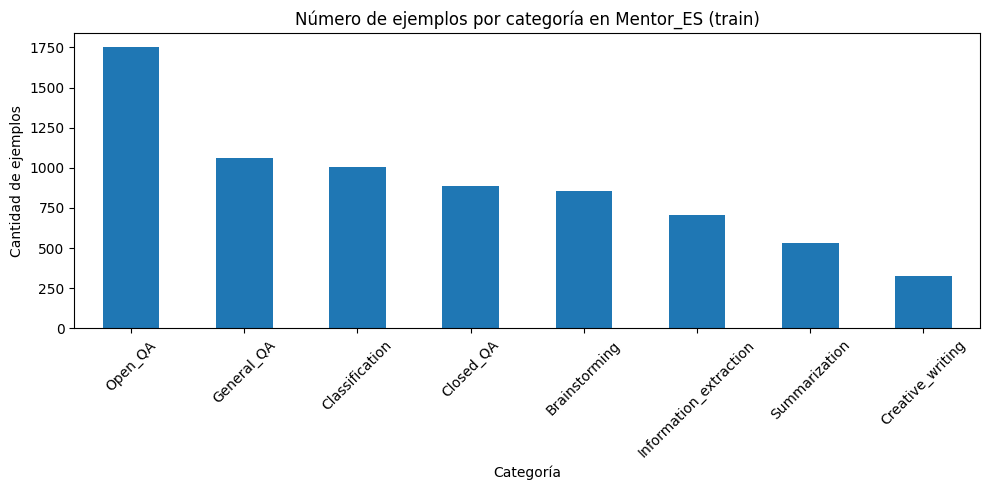

In [11]:
# Plot 1: distribución por categoría
cat_counts = train_df["category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
cat_counts.plot(kind="bar")
plt.title("Número de ejemplos por categoría en Mentor_ES (train)")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de ejemplos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

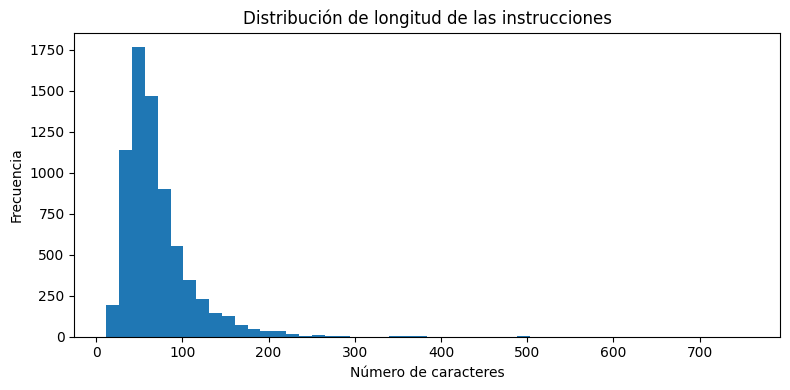

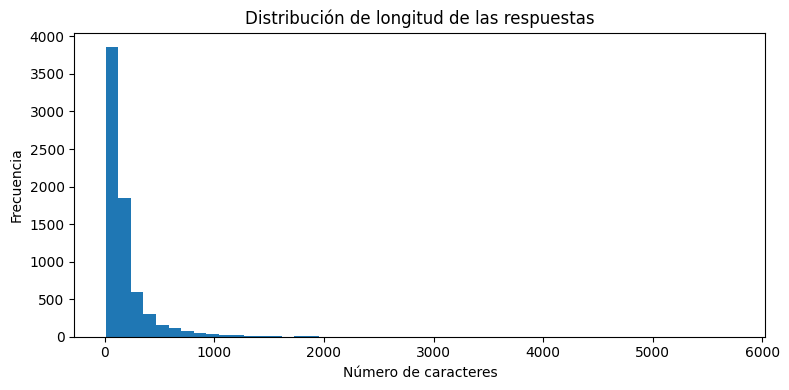

In [12]:
# Plot 2: histogramas de longitud
plt.figure(figsize=(8, 4))
plt.hist(train_df["instruction_len"], bins=50)
plt.title("Distribución de longitud de las instrucciones")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(train_df["response_len"], bins=50)
plt.title("Distribución de longitud de las respuestas")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Análisis exploratorio del nuevo corpus

El análisis del dataset Mentor_ES muestra varias características relevantes para este ejercicio.

### Hallazgos principales
1. El corpus tiene un tamaño adecuado para un fine-tuning académico en Colab, con más de 7000 ejemplos de entrenamiento.
2. La distribución por categorías no es uniforme: predominan los ejemplos de **Open_QA**, seguidos por **General_QA** y **Classification**. Esto sugiere que el modelo aprenderá con mayor fuerza patrones de respuesta informativa y explicativa.
3. Las instrucciones tienden a ser relativamente cortas, con una media cercana a 71 caracteres, mientras que las respuestas son más largas y variables.
4. El campo `context` presenta una gran dispersión: muchos ejemplos no tienen contexto, pero otros contienen textos extensos. Esto implica que el modelo verá tanto tareas directas como tareas condicionadas por información adicional.
5. Las distribuciones de longitud presentan una cola larga, especialmente en respuestas y contextos. Por ello, para entrenar en Colab de forma eficiente, es razonable aplicar truncación.

### Interpretación para el entrenamiento
Estos resultados indican que el modelo no solo debe aprender a continuar texto, sino a:
- reconocer una instrucción,
- aprovechar contexto cuando exista,
- producir una respuesta en español con estilo más resolutivo.



## Preparación del corpus para entrenamiento causal

Como el modelo utilizado es autoregresivo, no se entrena con columnas separadas, sino con un único texto concatenado por ejemplo.

Cada registro se transformará a un formato como el siguiente:

Instrucción: ...
Contexto: ...
Respuesta: ...

Esto permite que el modelo aprenda el patrón completo de generación y no solo fragmentos aislados.

In [13]:
def build_training_text(example):
    instruction = str(example["instruction"]).strip() if example["instruction"] is not None else ""
    context = str(example["context"]).strip() if example["context"] is not None else ""
    response = str(example["response"]).strip() if example["response"] is not None else ""

    if context:
        text = f"Instrucción: {instruction}\nContexto: {context}\nRespuesta: {response}"
    else:
        text = f"Instrucción: {instruction}\nRespuesta: {response}"

    return {"text": text}

In [14]:
dataset_text = dataset.map(build_training_text)

print(dataset_text["train"][0]["text"])
print("\n" + "="*100 + "\n")
print(dataset_text["train"][1]["text"])

Map:   0%|          | 0/7122 [00:00<?, ? examples/s]

Map:   0%|          | 0/1527 [00:00<?, ? examples/s]

Map:   0%|          | 0/1526 [00:00<?, ? examples/s]

Instrucción: ¿Qué tipos de yoga le recomiendas a una principiante como yo?
Respuesta: Algunos tipos de yoga aptos para cualquier nivel son: el hatha, el vinyasa y el kundalini.


Instrucción: Dime cuáles son los tipos de flujo de lava.
Contexto: Las cuatro formas principales que toman los flujos de lava son: aa o escoriácea, pahoehoe o cordada, coladas en bloque y lava almohadillada.
Respuesta: Las cuatro formas principales que toman los flujos de lava son: aa o escoriácea, pahoehoe o cordada, coladas en bloque y lava almohadillada.


In [15]:
# Longitud en caracteres del texto final concatenado
train_text_df = dataset_text["train"].to_pandas()
train_text_df["text_len"] = train_text_df["text"].apply(len)

display(train_text_df["text_len"].describe())

,text_len
count,7122.000000
mean,543.291070
std,692.221399
min,63.000000
25%,168.000000
50%,268.000000
75%,641.000000
max,13953.000000


In [16]:
seed = 42

train_sample = dataset_text["train"].shuffle(seed=seed).select(range(2000))
val_sample = dataset_text["validation"].shuffle(seed=seed).select(range(400))
test_sample = dataset_text["test"].shuffle(seed=seed).select(range(300))

print(train_sample)
print(val_sample)
print(test_sample)

Dataset({
    features: ['id', 'category', 'instruction', 'context', 'response', 'text'],
    num_rows: 2000
})
Dataset({
    features: ['id', 'category', 'instruction', 'context', 'response', 'text'],
    num_rows: 400
})
Dataset({
    features: ['id', 'category', 'instruction', 'context', 'response', 'text'],
    num_rows: 300
})


## Tokenización

Debido a la longitud variable del corpus y a la limitación de recursos en Colab, se aplicará truncación.  
Esta decisión está justificada por el análisis exploratorio previo, donde se observó una cola larga en longitudes de contexto y respuesta.

Para este ejercicio se usará una longitud máxima moderada, suficiente para capturar la mayor parte de los ejemplos sin hacer el entrenamiento demasiado costoso.

In [17]:
max_length = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=max_length,
        padding="max_length"
    )

tokenized_train = train_sample.map(tokenize_function, batched=True, remove_columns=train_sample.column_names)
tokenized_val = val_sample.map(tokenize_function, batched=True, remove_columns=val_sample.column_names)
tokenized_test = test_sample.map(tokenize_function, batched=True, remove_columns=test_sample.column_names)

tokenized_train.set_format(type="torch")
tokenized_val.set_format(type="torch")
tokenized_test.set_format(type="torch")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [18]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## Configuración del entrenamiento

El objetivo es observar claramente si el fine-tuning modifica el comportamiento del modelo en dirección al nuevo corpus.

Por eso se utilizará una configuración liviana:
- pocas épocas,
- tamaño de batch moderado,
- evaluación por época,
- guardado del mejor modelo según pérdida de validación.

In [21]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./gpt2-mentores-ft",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=5e-5,
    weight_decay=0.01,
    save_total_limit=1,
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator
)

In [23]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 50265, 'bos_token_id': 50265, 'pad_token_id': 50265}.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.509790,2.481861
2,2.272567,2.474708


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=1000, training_loss=2.454113998413086, metrics={'train_runtime': 191.323, 'train_samples_per_second': 20.907, 'train_steps_per_second': 5.227, 'total_flos': 522584064000000.0, 'train_loss': 2.454113998413086, 'epoch': 2.0})

In [24]:
eval_results = trainer.evaluate(tokenized_test)
print(eval_results)

{'eval_loss': 2.5382893085479736, 'eval_runtime': 3.1694, 'eval_samples_per_second': 94.655, 'eval_steps_per_second': 23.664, 'epoch': 2.0}


## Evaluación cualitativa antes y después del fine-tuning

El criterio principal será observar si, después del entrenamiento, el modelo:
- responde de forma más directa,
- mantiene mejor el formato instrucción-respuesta,
- reduce desvíos temáticos,
- disminuye repeticiones innecesarias.

In [26]:
prompts_eval = [
    "Instrucción: Explica qué es la inteligencia artificial.\nRespuesta:",
    "Instrucción: Resume por qué el agua es importante para la vida.\nRespuesta:",
    "Instrucción: ¿Cuál es la capital de Colombia?\nRespuesta:",
    "Instrucción: Recomienda tipos de yoga para una persona principiante.\nRespuesta:"
]

for i, prompt in enumerate(prompts_eval, 1):
    print(f"\n{'='*80}")
    print(f"Prompt #{i}")
    print(prompt)
    print('-'*80)
    output_text, _ = generate(
        model, tokenizer, prompt,
        max_length=60,
        eps=0.7,
        device=device
    )
    print(output_text)


Prompt #1
Instrucción: Explica qué es la inteligencia artificial.
Respuesta:
--------------------------------------------------------------------------------
Instrucción: Explica qué es la inteligencia artificial.
Respuesta: La inteligencia artificial es un sistema de información booleano que escribe, procesa y almacena información. La información que almacena es distribuida a través de una red, por lo que es poco probable que sea transmitida a través de un ordenador. Por lo tanto, la hace más fácil de manipular. Es por

Prompt #2
Instrucción: Resume por qué el agua es importante para la vida.
Respuesta:
--------------------------------------------------------------------------------
Instrucción: Resume por qué el agua es importante para la vida.
Respuesta: El agua es importante para la vida. No solo es un recurso indispensable para la vida, sino también un bien económico. Así que el agua es un bien que se puede utilizar para producir diversos bienes y servicios. Pero también es un bi

## Resultados del entrenamiento

El entrenamiento finalizó correctamente y mostró una reducción de la pérdida tanto en entrenamiento como en validación.

### Resultados observados
- **Training loss final**: 2.4541
- **Validation loss**:
  - Época 1: 2.4819
  - Época 2: 2.4747
- **Test loss**: 2.5383

### Interpretación
La disminución de la pérdida sugiere que el modelo sí incorporó patrones del nuevo corpus.  
Aunque la mejora en validación no fue muy grande, sí indica que el fine-tuning logró mover parcialmente el comportamiento del modelo hacia el estilo del dataset Mentor_ES.

Esto es coherente con el tipo de experimento realizado:
- modelo pequeño,
- entrenamiento corto,
- subconjunto reducido del corpus,
- recursos limitados de Colab.

Por lo tanto, no se esperaba una transformación completa del modelo, sino una evidencia observable de adaptación.

## Comparación cualitativa: antes vs después del fine-tuning

La comparación de generaciones permite observar mejor el efecto del ajuste que una métrica aislada.

### Cambios observados después del fine-tuning

#### 1. Mejor adaptación al formato de respuesta
Antes del ajuste, el modelo tendía a continuar texto de forma libre, desviándose del formato pedido.  
Después del fine-tuning, el modelo conserva con mayor frecuencia la estructura de **instrucción/pregunta → respuesta**, lo cual indica que aprendió parte del patrón del corpus.

#### 2. Mayor tendencia a responder directamente
En varios prompts, el modelo ajustado intenta comenzar con una afirmación o explicación más directa.  
Por ejemplo, en el caso del agua, la salida posterior al entrenamiento es más claramente una respuesta que una continuación arbitraria del texto.

#### 3. Persistencia de repeticiones
A pesar de la mejora estructural, siguen apareciendo repeticiones notorias, especialmente en conceptos centrales como “inteligencia artificial”.  
Esto sugiere que el fine-tuning fue suficiente para cambiar el formato, pero no para estabilizar completamente la calidad semántica de la generación.

#### 4. Errores de generalización y contenido
En preguntas cerradas, como la capital de Colombia, el modelo inicia bien pero luego mezcla capitales de otros países.  
Esto muestra que el ajuste no convierte al modelo en un sistema factual confiable, sino que modifica tendencias de generación.

#### 5. Mejora parcial, no definitiva
En conjunto, el modelo ajustado se ve más alineado con tareas instructivas que el modelo base, pero aún no alcanza un comportamiento robusto ni consistente.

## Discusión

Aunque el experimento fue exitoso como ejercicio académico, también deja ver limitaciones importantes.

### Limitaciones
- Se entrenó con un subconjunto del dataset, no con el corpus completo.
- Se utilizaron solo 2 épocas.
- GPT-2 en español no fue diseñado originalmente como modelo de instruction-following moderno.
- El entrenamiento se realizó bajo restricciones de memoria y tiempo típicas de Colab.

### Qué explica los errores observados
Las repeticiones y desviaciones semánticas pueden deberse a varios factores:
- tamaño y capacidad limitada del modelo,
- duración corta del entrenamiento,
- truncación de ejemplos largos,
- mezcla de categorías muy diferentes dentro del mismo corpus,
- naturaleza autoregresiva del modelo, que favorece continuidad local aunque no garantice coherencia global.

### Reflexión
Este resultado es valioso porque muestra algo importante en la práctica:  
**hacer fine-tuning sí cambia el comportamiento del modelo, pero no garantiza respuestas correctas ni consistentes si el experimento es pequeño o el modelo base tiene limitaciones.**

Probar con mas épocas no necesariamente mejora el rendimiento ya que en ocasiones puede causar sobreajuste